In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



In [8]:
df = pd.read_csv("../data/processed/survey_cleaned.csv")

In [10]:
features = df[['ads_interrupt_usage_score',
               'ads_cause_frustration_score',
               'ads_reduce_enjoyment_score',
               'ads_close_app_score',
               'ad_fatigue_index']]

In [12]:
features = features.fillna(features.mean())

In [14]:
features = features.dropna()

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

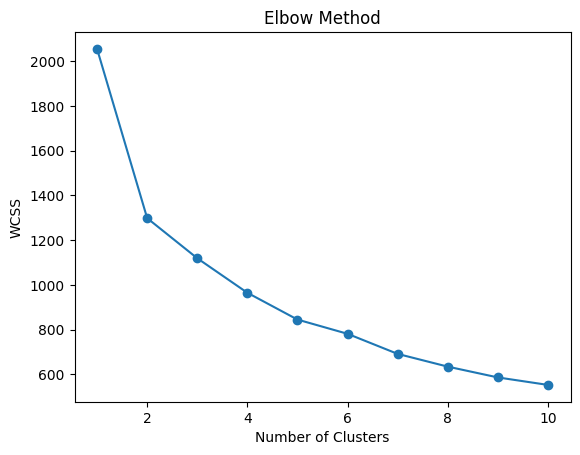

In [18]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,age_group,occupation,gender,smartphone_type,screen_time,daily_app_categories,most_used_category,ad_frequency,frequent_ad_format,most_excessive_ad_category,...,ads_uninstall_app,tolerated_ad_format,most_annoying_ad_time,pay_for_adfree,ads_interrupt_usage_score,ads_cause_frustration_score,ads_reduce_enjoyment_score,ads_close_app_score,ad_fatigue_index,Cluster
0,18–24,Student,Male,Android,4–6 hours,"Social Media, Video / OTT, Gaming, Shopping / ...","Social Media, Video / OTT, Gaming",Often,Unskippable ads,Gaming,...,Yes,Skippable video ads,Evening,No,4.0,5.0,5.0,3.0,4.25,2
1,18–24,Student,Male,iOS,4–6 hours,"Social Media, Video / OTT, Education","Social Media, Video / OTT, Education",Often,Video ads,Video / OTT,...,Yes,Skippable video ads,Evening,Yes,5.0,5.0,4.0,4.0,4.50,2
2,18–24,Student,Male,iOS,More than 6 hours,"Social Media, Video / OTT, Gaming","Social Media, Video / OTT, Gaming",Sometimes,Sponsored posts,Social Media,...,No,Skippable video ads,Evening,Yes,4.0,5.0,5.0,2.0,4.00,2
3,18–24,Student,Male,Android,4–6 hours,"Social Media, Video / OTT, Shopping / E-commer...","Social Media, Shopping / E-commerce, Education",Sometimes,Video ads,Social Media,...,Yes,Rewarded ads,NaN,Yes,3.0,4.0,4.0,3.0,3.50,0
4,Below 18,Student,Female,iOS,2–4 hours,"Social Media, Video / OTT, Shopping / E-commerce","Social Media, Video / OTT, Shopping / E-commerce",Sometimes,Banner ads,Video / OTT,...,No,Banner ads,Morning,No,3.0,3.0,4.0,2.0,3.00,0


In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['ads_interrupt_usage_score',
               'ads_cause_frustration_score',
               'ads_reduce_enjoyment_score',
               'ads_close_app_score',
               'ad_fatigue_index']]

features = features.fillna(features.mean())

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

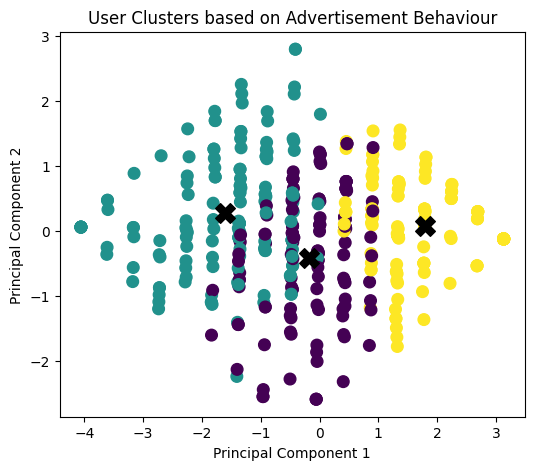

In [36]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select features
features = df[['ads_interrupt_usage_score',
               'ads_cause_frustration_score',
               'ads_reduce_enjoyment_score',
               'ads_close_app_score',
               'ad_fatigue_index']]

features = features.fillna(features.mean())

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(features)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1],
            c=clusters,
            cmap='viridis',
            s=70)

centers = pca.transform(kmeans.cluster_centers_)

plt.scatter(centers[:,0], centers[:,1],
            c='black',
            s=200,
            marker='X')

plt.title("User Clusters based on Advertisement Behaviour")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

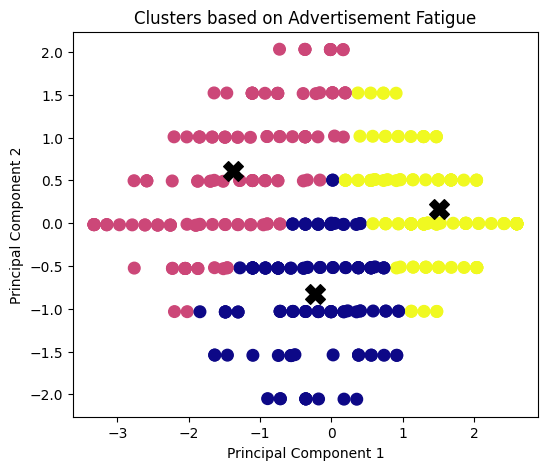

In [38]:
features2 = df[['ads_interrupt_usage_score',
                'ads_close_app_score',
                'ad_fatigue_index']]

features2 = features2.fillna(features2.mean())

scaler = StandardScaler()
X2 = scaler.fit_transform(features2)

kmeans2 = KMeans(n_clusters=3, random_state=42)
clusters2 = kmeans2.fit_predict(X2)

pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(X2)

plt.figure(figsize=(6,5))

plt.scatter(X2_pca[:,0], X2_pca[:,1],
            c=clusters2,
            cmap='plasma',
            s=70)

centers2 = pca2.transform(kmeans2.cluster_centers_)

plt.scatter(centers2[:,0], centers2[:,1],
            c='black',
            s=200,
            marker='X')

plt.title("Clusters based on Advertisement Fatigue")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()